# DengAI Dataset: Predicting Dengue Disease Spread
**Authors:** Joshua Owen Mangotang, Dastan Nurbekuly

Dataset Sources: https://www.drivendata.org/competitions/44/dengai-predicting-disease-spread/page/82/#features_list

**Authors**: Dastan Nurbekuly and Joshua Mangotang

## Phase 1: Introduction


This dataset comes from a data science competition with the goal of predicting the number of dengue fever cases per week in two cities — San Juan (Puerto Rico) and Iquitos (Peru) — based on climatological and environmental data.

Dengue transmission is closely linked to environmental conditions since the Aedes mosquito, which carries the virus, depends heavily on temperature, humidity, and precipitation for breeding and survival.

The data was collected from multiple sources under the Predict the Next Pandemic Initiative. Dengue surveillance data was provided by the U.S. Centers for Disease Control and Prevention (CDC), along with the Department of Defense’s Naval Medical Research Unit 6 and the Armed Forces Health Surveillance Center, in collaboration with the Peruvian government and U.S. universities. Environmental and climate variables were supplied by the National Oceanic and Atmospheric Administration (NOAA). The complete dataset includes weekly time-series data containing:
- Climatological features (e.g., temperature, humidity, precipitation, vegetation index)
- Total dengue cases (target variable)

Since the two cities differ quite significantly in climate and sample size, this analysis focuses only on San Juan, which has the longest observation period.

Each record represents a week of data, containing multiple numerical climate features and an integer label indicating the number of dengue cases observed. The dataset spans approximately 18 years, offering rich temporal patterns for modeling and prediction.

In [1]:
%matplotlib inline

from __future__ import print_function
from __future__ import division

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

from warnings import filterwarnings
filterwarnings('ignore')

# load the provided data, index column = 'city', 'year', week of year'
train_features = pd.read_csv('dengue_features_train.csv',
                             index_col=[0,1,2])

train_labels = pd.read_csv('dengue_labels_train.csv',
                           index_col=[0,1,2])

test_features = pd.read_csv('dengue_features_test.csv',
                           index_col=[0,1,2])

# Separate data for San Juan
sj_train_features = train_features.loc['sj']
sj_train_labels = train_labels.loc['sj']
sj_train_features['total_cases'] = sj_train_labels.total_cases

# Separate data for Iquitos (Optional for future use)
iq_train_features = train_features.loc['iq']
iq_train_labels = train_labels.loc['iq']
iq_train_features['total_cases'] = iq_train_labels.total_cases

### Features and Output Variable

The San Juan dataset contains a total of 22 features, most of which are numerical. These features can be grouped into three main categories based on their environmental purpose:
- **NDVI Features** represent vegetation coverage around the city using satellite imagery:
ndvi_ne, ndvi_nw, ndvi_se, ndvi_sw
- **Precipitation Features** capture different sources of rainfall measurement:
precipitation_amt_mm, reanalysis_precip_amt_kg_per_m2, reanalysis_sat_precip_amt_mm, station_precip_mm
- **Temperature Features** describe various aspects of air temperature and thermal variability:
reanalysis_air_temp_k, reanalysis_avg_temp_k, reanalysis_max_air_temp_k, reanalysis_min_air_temp_k,
reanalysis_tdtr_k, station_avg_temp_c, station_max_temp_c, station_min_temp_c, station_diur_temp_rng_c

The output variable is `total_cases`, an integer feature indicating the number of reported dengue cases per week. This is the target variable that the model aims to predict.

In [2]:
sj_train_features.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 936 entries, (np.int64(1990), np.int64(18)) to (np.int64(2008), np.int64(17))
Data columns (total 22 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   week_start_date                        936 non-null    object 
 1   ndvi_ne                                745 non-null    float64
 2   ndvi_nw                                887 non-null    float64
 3   ndvi_se                                917 non-null    float64
 4   ndvi_sw                                917 non-null    float64
 5   precipitation_amt_mm                   927 non-null    float64
 6   reanalysis_air_temp_k                  930 non-null    float64
 7   reanalysis_avg_temp_k                  930 non-null    float64
 8   reanalysis_dew_point_temp_k            930 non-null    float64
 9   reanalysis_max_air_temp_k              930 non-null    float64
 10  reanalysis_min_air

## Figures

This section presents key visualizations that help describe the dengue case patterns and overall behavior of the dataset over time.

### Time Series of Target Data

The time-series plot of the `total_cases` variable shows how dengue cases fluctuate across weeks (Figure 1).
We can observe distinct seasonal patterns, with periodic spikes representing outbreak periods in certain years. These peaks reflect how dengue transmission tends to increase during specific environmental conditions, such as warmer and wetter seasons.

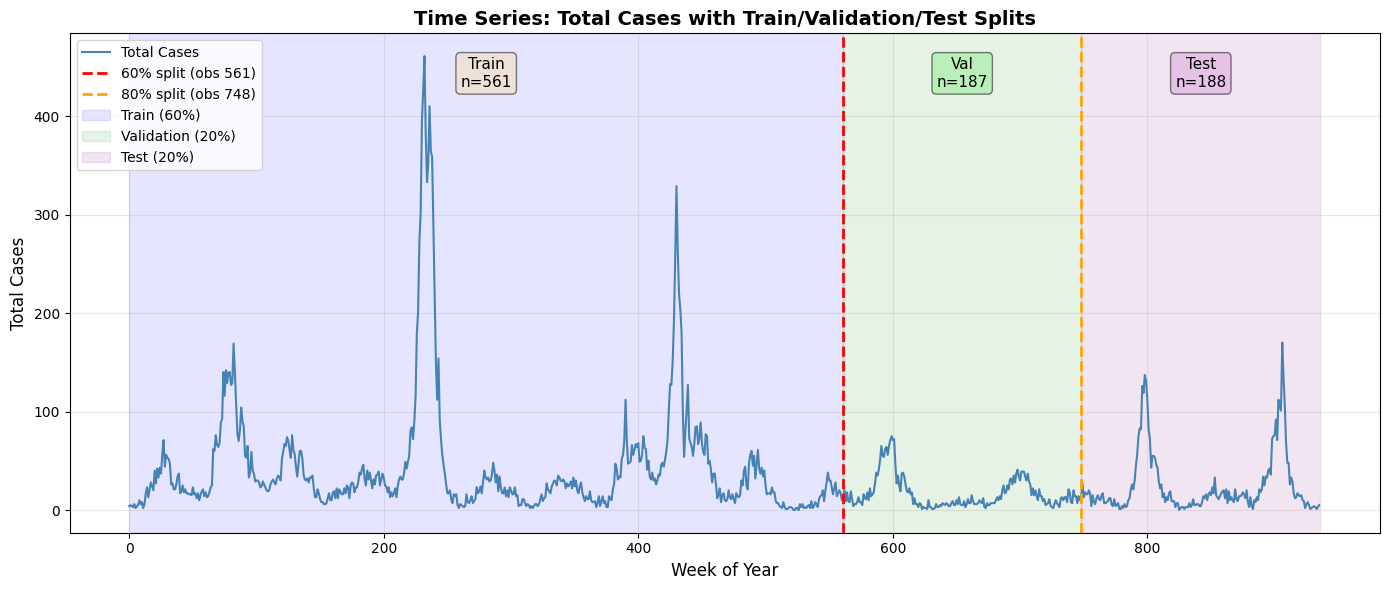

In [3]:
# Get the data
total_cases = sj_train_features['total_cases']

# Calculate split points
n_obs = len(total_cases)
split_60 = int(n_obs * 0.60)
split_80 = int(n_obs * 0.80)

# Create the plot
plt.figure(figsize=(14, 6))

# Plot the time series
plt.plot(range(n_obs), total_cases.values, linewidth=1.5, color='steelblue', label='Total Cases')

# Draw vertical lines at split points
plt.axvline(x=split_60, color='red', linestyle='--', linewidth=2, label=f'60% split (obs {split_60})')
plt.axvline(x=split_80, color='orange', linestyle='--', linewidth=2, label=f'80% split (obs {split_80})')

# Add shaded regions to show the splits
plt.axvspan(0, split_60, alpha=0.1, color='blue', label='Train (60%)')
plt.axvspan(split_60, split_80, alpha=0.1, color='green', label='Validation (20%)')
plt.axvspan(split_80, n_obs, alpha=0.1, color='purple', label='Test (20%)')

# Labels and title
plt.xlabel('Week of Year', fontsize=12)
plt.ylabel('Total Cases', fontsize=12)
plt.title('Time Series: Total Cases with Train/Validation/Test Splits', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)

# Add text annotations showing the counts
plt.text(split_60/2, plt.ylim()[1]*0.95, f'Train\nn={split_60}', 
         ha='center', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.text((split_60+split_80)/2, plt.ylim()[1]*0.95, f'Val\nn={split_80-split_60}', 
         ha='center', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
plt.text((split_80+n_obs)/2, plt.ylim()[1]*0.95, f'Test\nn={n_obs-split_80}', 
         ha='center', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='plum', alpha=0.5))

plt.tight_layout()
plt.show()

*Figure 1. Time series of Total cases.*

### Label Distribution

The label distribution illustrates the frequency of dengue case counts across all weeks (Figure 2).
It reveals that most weeks have low or zero cases, while a few weeks experience very high case counts, forming a right-skewed distribution. This pattern indicates overdispersion, a common characteristic of epidemic data where outbreaks occur irregularly but with high intensity.

San Juan
Mean : 34.18
Variance : 2640.05


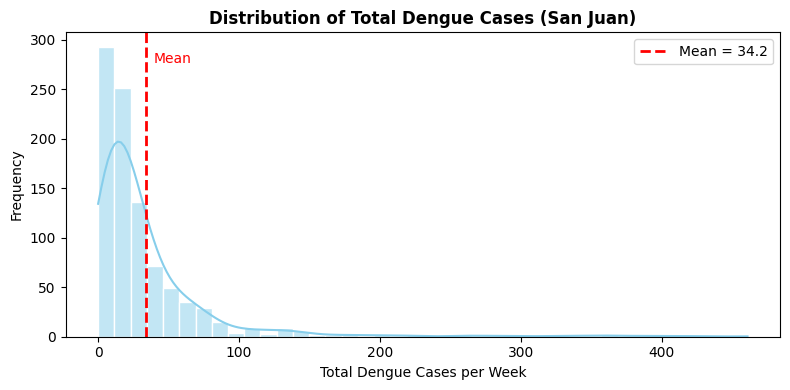

In [4]:
mean_cases = sj_train_labels['total_cases'].mean()
var_cases = sj_train_labels['total_cases'].var()

print("San Juan")
print(f"Mean : {mean_cases:.2f}")
print(f"Variance : {var_cases:.2f}")

# Plot distribution
plt.figure(figsize=(8, 4))
sns.histplot(sj_train_labels['total_cases'], kde=True, bins=40, color='skyblue', edgecolor='white')

# Add title and labels
plt.title('Distribution of Total Dengue Cases (San Juan)', fontsize=12, weight='bold')
plt.xlabel('Total Dengue Cases per Week')
plt.ylabel('Frequency')

# Add mean and variance lines
plt.axvline(mean_cases, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_cases:.1f}')
plt.text(mean_cases + 5, plt.ylim()[1]*0.9, 'Mean', color='red')

plt.legend()
plt.tight_layout()
plt.show()

*Figure 2. Distribution of the label data.*

### Feature Correlations with Label (`total_cases`)

Figure 3 illustrates the linear correlation between each feature and the target variable total_cases.
From the visualization, we can see that some feature groups — particularly temperature-related variables — tend to have stronger correlations with dengue cases compared to others.

This suggests that temperature and humidity likely play key roles in influencing mosquito activity and virus transmission, while other features such as NDVI or diurnal temperature range may have weaker or indirect effects.

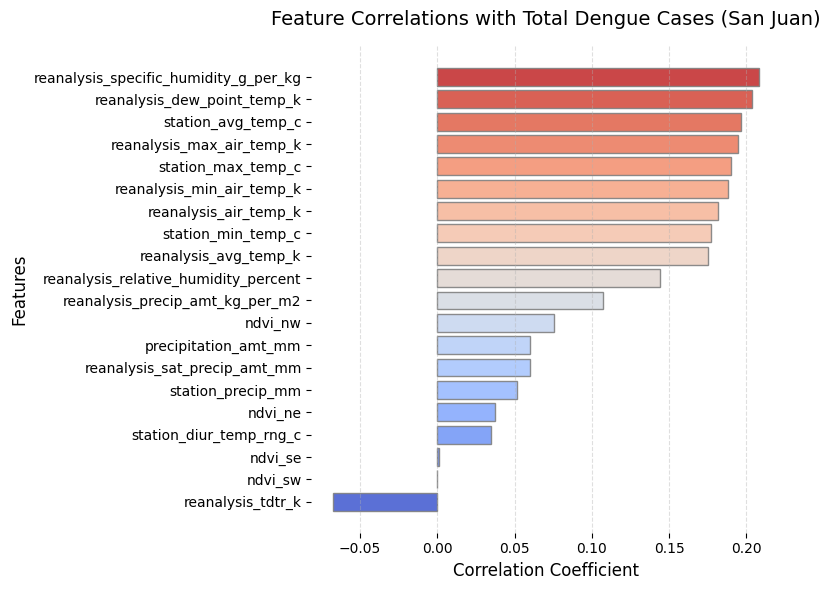

In [5]:
# Merge features + labels
sj_corr = sj_train_features.copy()
sj_corr['total_cases'] = sj_train_labels['total_cases']
sj_corr_numeric = sj_corr.select_dtypes(include=[np.number])

# Compute correlation with target
corr_target = sj_corr_numeric.corr()['total_cases'].drop('total_cases').sort_values(ascending=True)

# Set up figure
plt.figure(figsize=(8, 6))

# Create bars
bars = plt.barh(
    corr_target.index, 
    corr_target.values, 
    color=sns.color_palette("coolwarm", len(corr_target)), 
    edgecolor='gray', 
    alpha=0.9
)

# Titles and labels
plt.title('Feature Correlations with Total Dengue Cases (San Juan)', fontsize=14, pad=15)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Clean up style
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

*Figure 3. Correlation Coefficients between Label and Features.*

### Descriptive Statistical Analysis

The code below provides a statistical summary of all features in the dataset, including their mean, standard deviation, minimum, and maximum values.
It helps us understand the range, central tendency, and spread of each variable, as well as detect any potential outliers or inconsistencies in the data.

Additionally, the total dataset size for San Juan is displayed, representing the number of weekly observations available for analysis.

In [6]:
# Add labels to features for complete analysis
sj_train_features['total_cases'] = sj_train_labels.total_cases

# Statistical Summary
print("DATASET STATISTICS")
print(sj_train_features.describe())

# Dataset size
print(f"\nDATASET SIZES")
print(f"San Juan train: {len(sj_train_features)} weeks")

DATASET STATISTICS
          ndvi_ne     ndvi_nw     ndvi_se     ndvi_sw  precipitation_amt_mm  \
count  745.000000  887.000000  917.000000  917.000000            927.000000   
mean     0.057925    0.067469    0.177655    0.165956             35.470809   
std      0.107153    0.092479    0.057166    0.056073             44.606137   
min     -0.406250   -0.456100   -0.015533   -0.063457              0.000000   
25%      0.004500    0.016425    0.139283    0.129157              0.000000   
50%      0.057700    0.068075    0.177186    0.165971             20.800000   
75%      0.111100    0.115200    0.212557    0.202771             52.180000   
max      0.493400    0.437100    0.393129    0.381420            390.600000   

       reanalysis_air_temp_k  reanalysis_avg_temp_k  \
count             930.000000             930.000000   
mean              299.163653             299.276920   
std                 1.236429               1.218637   
min               295.938571             296.1142

### Missing Values

Missing data is present in features (Figure 4). For example, in San Juan, `ndvi_ne` has a missing percentage exceeding 20%, and `ndvi_nw` is missing around 5% of its values.

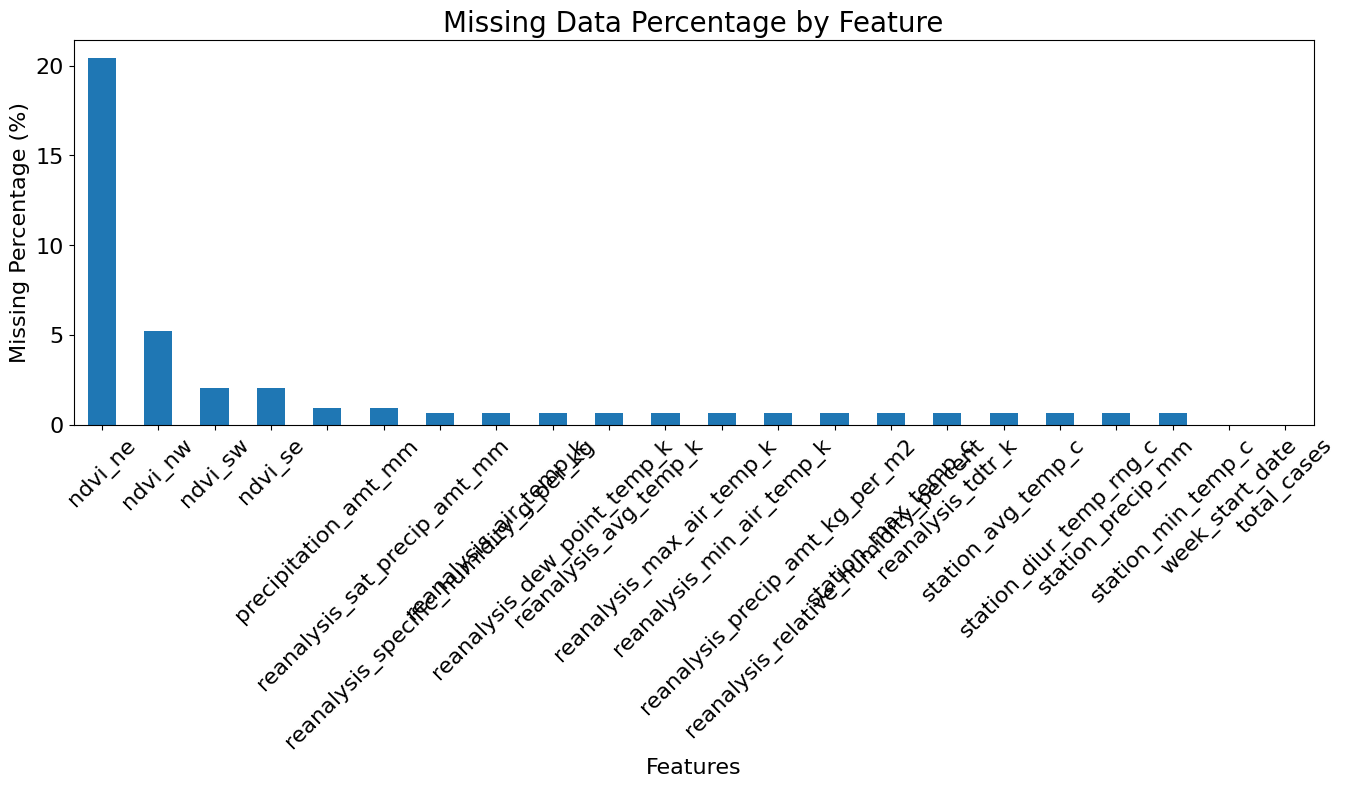

In [7]:
# Calculate missing data percentage
sj_missing_pct = (sj_train_features.isnull().sum() / len(sj_train_features)) * 100
sj_missing_pct = sj_missing_pct.sort_values(ascending=False)

# Plot
sj_missing_pct.plot(kind='bar', figsize=(16,5))
plt.title('Missing Data Percentage by Feature', fontsize=20)
plt.xlabel('Features', fontsize=16)
plt.ylabel('Missing Percentage (%)', fontsize=16)
plt.tick_params(axis='x', rotation=45, labelsize=16)
plt.tick_params(axis='y', labelsize=16)

*Figure 4. Missing values across features in %.*

# Phase 2: Preprocessing, Hyperparameters and Model Training

### Preprocessing Techniques 

- **Linear Interpolation**: This method is used to fill missing values, ensuring climate variables change gradually and avoiding artificial oscillations in the time series.

- **Lagged Features**: Since dengue transmission is not instantaneous, using lagged features can improve model performance. A lagged feature $X_t(lag=k)$ is simply the feature value from $k$ time steps prior: $X_t(lag=k)=X_{t-k}$

- **Target Transformation**: An important consideration is the log transformation of the target variable, $log(1+y)$, given the skewed label distribution.

- **Feature Engineering**: As shown in the target plot (Figure 1), the label exhibits sharp peaks representing outbreak periods. To understand the drivers of these peaks, we try to analyze the environmental variables during outbreak weeks and identified noticeable deviations.

## Preprocessing and Model Training
In this chapter, we apply preprocessing and model training step by step and conduct several controlled experiments. The objective is to understand how each preprocessing technique influences the behaviour and performance of the main machine learning model used in this study.

## 1. Random Forest Regressor
The Random Forest Regressor was selected as our main model because it combines many decision trees and averages their predictions, which helps reduce noise and improve stability. It handles non-linear relationships naturally and works well with datasets that contain seasonal behaviour and sudden outbreaks. This makes it a practical and reliable choice for our dengue data, where environmental variables interact in ways that traditional linear models cannot capture effectively.

#### Experiment 1: Base Model + No Preprocessing

In [2]:
def preprocess_data_vanilla(df: pd.DataFrame):
    # Defensive copy
    df = df.copy()

    # Check that target column exists
    if 'total_cases' not in df.columns:
        raise ValueError("DataFrame must contain a 'total_cases' column as the target.")

    # Split features and target
    feature_cols = [c for c in df.columns if c != 'total_cases']

    # Interpolate missing values in features only
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')

    # No shifting or log transformation
    df_processed = df.dropna().reset_index(drop=True)

    # Separate features and label
    X = df_processed[feature_cols]
    y = df_processed['total_cases']

    # Remove 'week_start_date' if present
    if 'week_start_date' in X.columns:
        X = X.drop(columns=['week_start_date'])

    return X, y, df_processed


In [4]:
X, Y, df_shifted = preprocess_data_vanilla(sj_train_features)

# Data splitting
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Trained on a vanilla model
random_forest = RandomForestRegressor(n_estimators=500, max_features=int(X.shape[1]/3), random_state=42)
random_forest.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = random_forest.predict(Xtrain)

# Training errors
train_mae = mean_absolute_error(Ytrain, Ytrain_pred)
train_rmse = np.sqrt(mean_squared_error(Ytrain, Ytrain_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors (already done)
Ypred = random_forest.predict(Xtest)
mae = mean_absolute_error(Ytest, Ypred)
rmse = np.sqrt(mean_squared_error(Ytest, Ypred))

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Training MAE: 10.46
Training RMSE: 17.76
Test MAE: 27.96
Test RMSE: 36.81


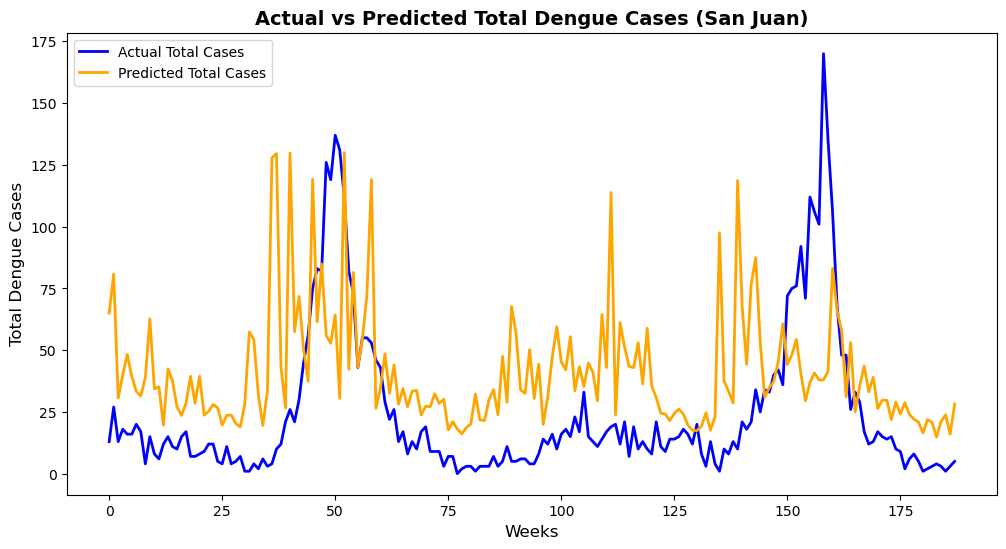

In [ ]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(Ytest.values, label='Actual Total Cases', color='blue', linewidth=2)
plt.plot(Ypred, label='Predicted Total Cases', color='orange', linewidth=2)
plt.title('Actual vs Predicted Total Dengue Cases (San Juan)', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Dengue Cases', fontsize=12)
plt.legend()
plt.show()

*Figure 5. Experiment 1 Actual vs Predicted Plot on Test Set*

As shown in *Figure 5*, the model is clearly underfitted. This is expected because no preprocessing was applied—particularly the lag transformation. Dengue incidence does not respond immediately to environmental changes, there is an inherent delay before conditions such as rainfall or temperature begin to influence case counts. Without incorporating this lag, the model cannot represent the underlying temporal dynamics, resulting in weak predictive performance.

#### Experiment 2: Base Model + Lag

In [5]:
def preprocess_data_lag(df: pd.DataFrame, lag: int = 10):
    # Defensive copy
    df = df.copy()

    # Check that target column exists
    if 'total_cases' not in df.columns:
        raise ValueError("DataFrame must contain a 'total_cases' column as the target.")

    # Split features and target
    feature_cols = [c for c in df.columns if c != 'total_cases']

    # Interpolate missing values in features
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')

    # Shift features forward by lag (to make them predictive)
    df_shifted = df.copy()
    df_shifted[feature_cols] = df_shifted[feature_cols].shift(lag)

    # Drop NaN rows introduced by shifting
    df_shifted = df_shifted.dropna().reset_index(drop=True)

    # Separate features and label
    X = df_shifted[feature_cols]
    y = df_shifted['total_cases']

    # Remove 'week_start_date' if present
    if 'week_start_date' in X.columns:
        X = X.drop(columns=['week_start_date'])

    return X, y, df_shifted

In [6]:
lag = 10
X, Y, df_shifted = preprocess_data_lag(sj_train_features, lag)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Remove first `lag` samples from test set
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

random_forest = RandomForestRegressor(n_estimators=500, max_features=int(X.shape[1]/3), random_state=42)
random_forest.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = random_forest.predict(Xtrain)

# Training errors
train_mae = mean_absolute_error(Ytrain, Ytrain_pred)
train_rmse = np.sqrt(mean_squared_error(Ytrain, Ytrain_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors (already done)
Ypred = random_forest.predict(Xtest)
mae = mean_absolute_error(Ytest, Ypred)
rmse = np.sqrt(mean_squared_error(Ytest, Ypred))

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Training MAE: 9.60
Training RMSE: 17.82
Test MAE: 23.55
Test RMSE: 30.46


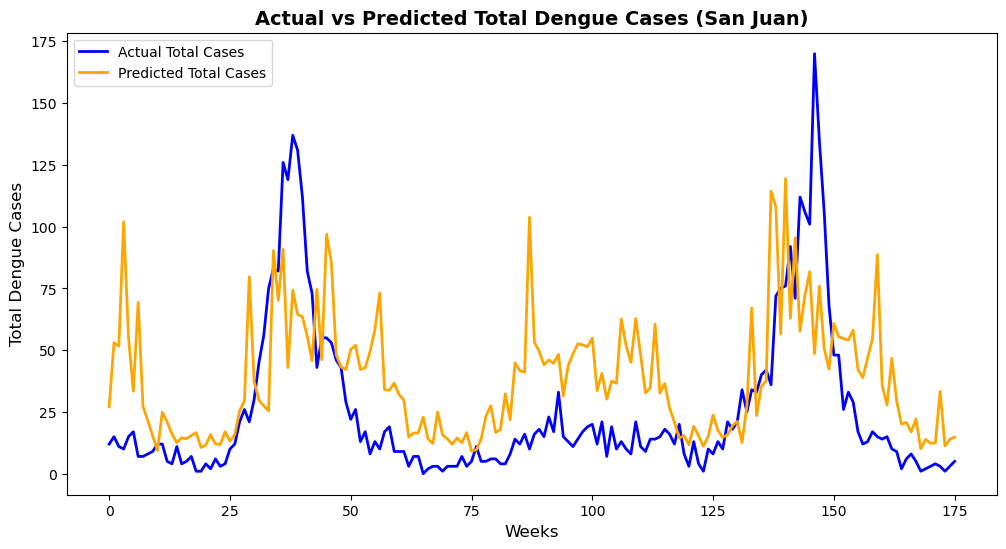

In [173]:
# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(Ytest.values, label='Actual Total Cases', color='blue', linewidth=2)
plt.plot(Ypred, label='Predicted Total Cases', color='orange', linewidth=2)
plt.title('Actual vs Predicted Total Dengue Cases (San Juan)', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Dengue Cases', fontsize=12)
plt.legend()
plt.show()

*Figure 6. Experiment 2 Actual vs Predicted on Test Set*

The figure demonstrates that the model's predictions are closely synchronized with the actual target values, capturing the overall pattern and trend quite well. However, the model still exhibits signs of underfitting, particularly due to its failure to accurately capture extreme values or sharp spikes. Therefore, the second essential step of preprocessing is applying a target transformation using the natural logarithm ($\ln$). This transformation is necessary because the original label distribution is positively skewed. Applying the log transformation compresses the magnitude of large values, resulting in a more symmetrical distribution that significantly aids the model's ability to learn and predict across the full range of the data.

#### Experiment 3: Base Model + Lag, Interpolation and log-Transform

In [7]:
def preprocess_data(df: pd.DataFrame, lag: int = 10):
    # Defensive copy
    df = df.copy()

    # Check that target column exists
    if 'total_cases' not in df.columns:
        raise ValueError("DataFrame must contain a 'total_cases' column as the target.")

    # Split features and target
    feature_cols = [c for c in df.columns if c != 'total_cases']
    
    # Interpolate missing values in features
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')

    # Shift features forward by lag (to make them predictive)
    df_shifted = df.copy()
    df_shifted[feature_cols] = df_shifted[feature_cols].shift(lag)

    # Log-transform the target  
    df_shifted['total_cases'] = np.log1p(df_shifted['total_cases'])

    # Drop NaN rows introduced by shifting
    df_shifted = df_shifted.dropna().reset_index(drop=True)

    # Separate features and label
    X = df_shifted[feature_cols]
    y = df_shifted['total_cases']

    # Remove 'week_start_date' if present
    if 'week_start_date' in X.columns:
        X = X.drop(columns=['week_start_date'])

    return X, y, df_shifted

In [8]:
lag = 10
X, Y, df_shifted = preprocess_data(sj_train_features, 10)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# Remove first `lag` samples from test set
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

random_forest = RandomForestRegressor(n_estimators=500, max_features=int(X.shape[1]/3), random_state=42, oob_score=True)
random_forest.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = random_forest.predict(Xtrain)

# Transform back from log1p
y_train_true = np.expm1(Ytrain)
y_train_pred = np.expm1(Ytrain_pred)

# Training errors
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors
Ypred = random_forest.predict(Xtest)

y_true = np.expm1(Ytest)
y_pred = np.expm1(Ypred)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Training MAE: 10.47
Training RMSE: 29.06
Test MAE: 17.05
Test RMSE: 28.98


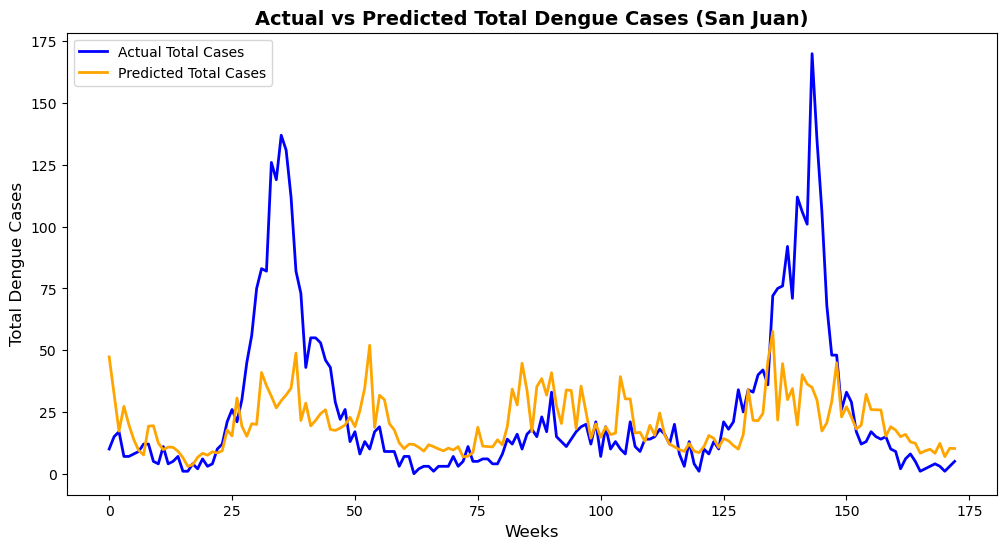

In [160]:
# Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_true.values, label='Actual Total Cases', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted Total Cases', color='orange', linewidth=2)
plt.title('Actual vs Predicted Total Dengue Cases (San Juan)', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Dengue Cases', fontsize=12)
plt.legend()
plt.show()

*Figure 7. Experiment 3 Actual vs Predicted on Test Set*

After applying interpolation and a log transformation, the model performance improved substantially, as reflected in the much lower error scores and the smoother target plot. Interpolation stabilised the training signal by filling missing observations consistently, while the log transform reduced the impact of extreme outbreak spikes. Together, these steps made the underlying patterns more learnable for the model and reduced noise-driven variance in the predictions.

#### Experiment 4: Base Model + Lag Features, log-Transform, Feature Engineering

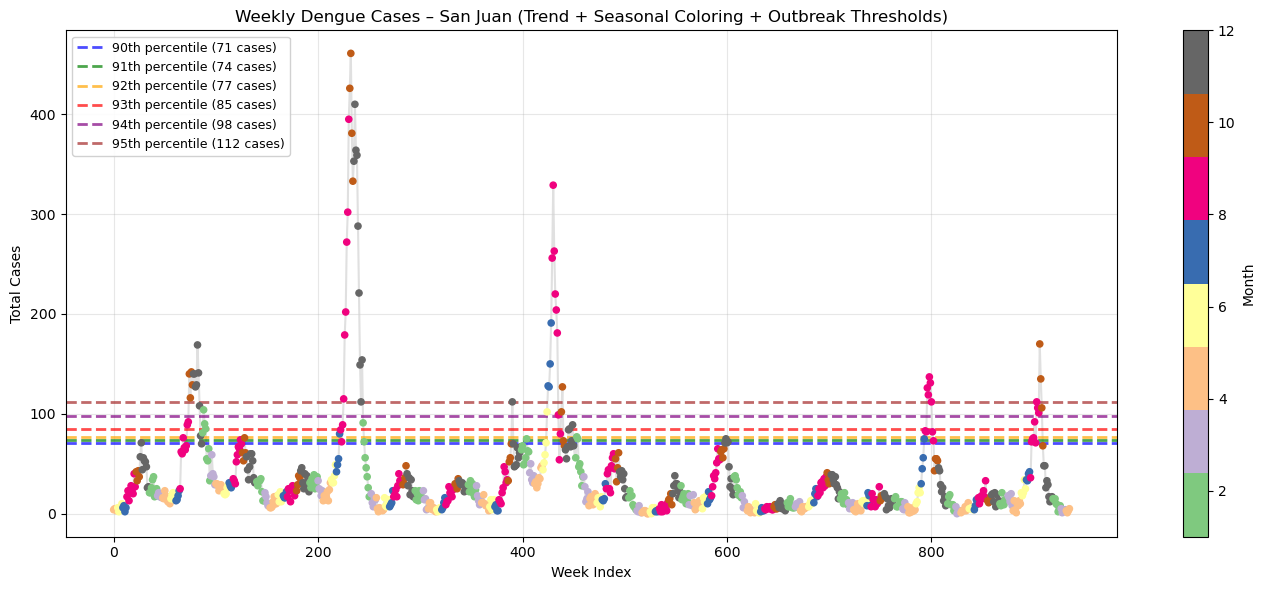

In [183]:
def week_to_month(week):
    if 1 <= week <= 4:
        return 1
    elif 5 <= week <= 8:
        return 2
    elif 9 <= week <= 13:
        return 3
    elif 14 <= week <= 17:
        return 4
    elif 18 <= week <= 21:
        return 5
    elif 22 <= week <= 26:
        return 6
    elif 27 <= week <= 30:
        return 7
    elif 31 <= week <= 35:
        return 8
    elif 36 <= week <= 39:
        return 9
    elif 40 <= week <= 43:
        return 10
    elif 44 <= week <= 48:
        return 11
    elif 49 <= week <= 52:
        return 12
    else:
        return np.nan

sj_train_labels_plot = sj_train_labels.reset_index()
sj_train_labels_plot['month'] = sj_train_labels_plot['weekofyear'].apply(week_to_month)

plt.figure(figsize=(14,6))

plt.plot(sj_train_labels_plot["total_cases"].values, color="lightgray", alpha=0.7, linewidth=1.5)

plt.scatter(
    range(len(sj_train_labels_plot)),
    sj_train_labels_plot["total_cases"],
    c=sj_train_labels_plot["month"],
    cmap="Accent",
    s=20,
    zorder=3
)

quantiles = [0.90, 0.91, 0.92, 0.93, 0.94, 0.95]
colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

for q, color in zip(quantiles, colors):
    threshold = sj_train_labels_plot['total_cases'].quantile(q)
    plt.axhline(
        y=threshold, 
        color=color, 
        linestyle='--', 
        linewidth=2, 
        alpha=0.7,
        label=f'{int(q*100)}th percentile ({threshold:.0f} cases)'
    )

plt.colorbar(label="Month")
plt.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.title("Weekly Dengue Cases – San Juan (Trend + Seasonal Coloring + Outbreak Thresholds)")
plt.ylabel("Total Cases")
plt.xlabel("Week Index")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 8.  Outbreak Tresholds Visualization*

The figure displays the data's seasonal pattern, helping to identify unusual events that could be considered outbreaks. Based on the plot and a pre-set threshold, values above the 93rd percentile are flagged as potential outbreaks. This visualization not only shows the necessary threshold for outbreak identification but also allows us to analyze the corresponding changes in the features during these high-risk periods, detecting unusual activity beyond typical seasonal expectations (highlighted by monthly color coding).

In [2]:
def outbreak_detection_features(train_features, train_labels, lag=1, threshold_quantile=0.8):
    train_features = train_features.copy()
    train_labels = train_labels.copy()

    # Join features and labels
    if "total_cases" in train_features.columns:
        train_features = train_features.drop(columns=["total_cases"])
    df_combined = train_features.join(train_labels['total_cases'], how='inner')
    
    # Apply time lag preprocessing
    X, y, df_shifted = preprocess_data(df_combined, lag=lag)
    
    # Convert log-transformed target back to original scale for outbreak detection
    df_shifted['total_cases_original'] = np.expm1(df_shifted['total_cases'])
    
    # Define outbreak threshold based on original scale
    threshold = train_labels['total_cases'].quantile(threshold_quantile)
    
    # Create outbreak label
    df_shifted['outbreak'] = (df_shifted['total_cases_original'] > threshold).astype(int)
    
    # Select numeric columns for analysis (exclude target and outbreak label)
    numeric_cols = df_shifted.select_dtypes(include=[np.number]).columns
    feature_cols = [c for c in numeric_cols if c not in ['total_cases', 'total_cases_original', 'outbreak']]
    
    # Calculate mean differences between outbreak and non-outbreak periods
    outbreak_means = df_shifted[df_shifted['outbreak'] == 1][feature_cols].mean()
    normal_means = df_shifted[df_shifted['outbreak'] == 0][feature_cols].mean()
    
    diff = outbreak_means - normal_means
    
    # Create visualization
    plt.figure(figsize=(10, 12))
    
    # Sort differences
    diff_sorted = diff.sort_values()
    
    # Plot
    colors = ['#d62728' if x > 0 else "#0274e6" for x in diff_sorted.values]
    plt.barh(diff_sorted.index, diff_sorted.values, color=colors, alpha=0.7)
    plt.axvline(0, color='black', linewidth=1.5)
    
    plt.title(f"Feature Mean Difference: Outbreak vs Non-Outbreak (Lag={lag})",
                fontsize=12, fontweight='bold')
    plt.xlabel("Mean Difference", fontsize=11)
    plt.ylabel("Features (Lagged)", fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()
    
    # Return results
    results = {
        'df_shifted': df_shifted,
        'X': X,
        'y': y,
        'outbreak_label': df_shifted['outbreak'],
        'feature_diff': diff,
        'threshold': threshold,
        'outbreak_means': outbreak_means,
        'normal_means': normal_means
    }
    
    return results

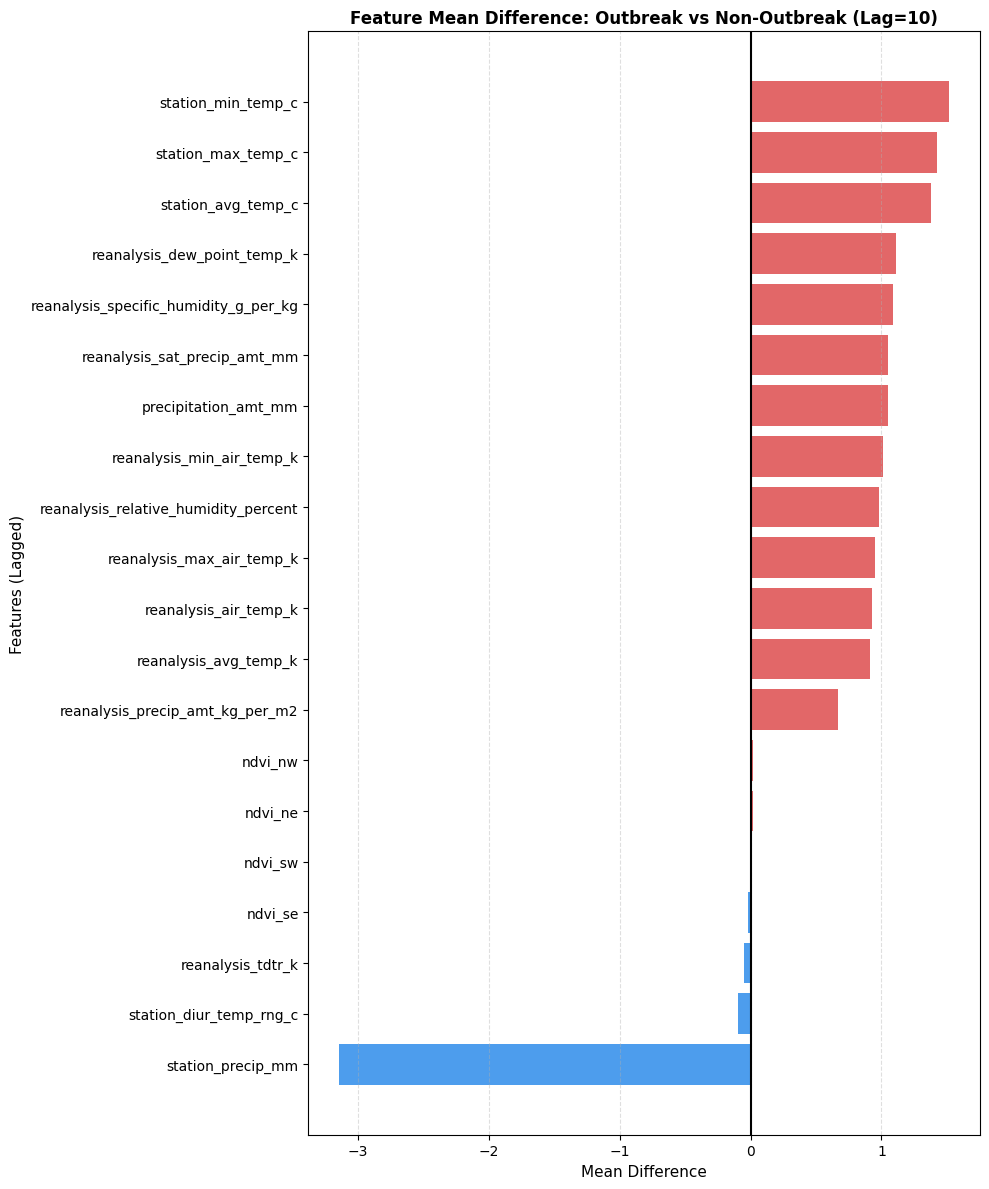

In [15]:
results = outbreak_detection_features(sj_train_features, sj_train_labels, lag=10, threshold_quantile=0.93)

*Figure 9. Features Mean Difference During Outbreak*

The figure above highlights anomalies in the `station_precip_mm` feature during outbreak periods. This observation suggests that incorporating such deviations into feature engineering could help the model capture unusual behavior in this variable, improving its ability to anticipate potential outbreaks. Therefore, we created the following features:
- `precip_roll_mean`: captures the short-term average precipitation level, providing the model with a smoother representation of typical rainfall conditions over a given window.
- `precip_roll_std`: reflects rainfall volatility; higher variability may signal unstable environmental conditions linked to outbreak risk.
- `precip_roll_min`: identifies unusually dry periods within the window, which can be relevant for understanding breeding-site dynamics before outbreaks.
- `precip_roll_max`: captures peak rainfall events, which are often associated with increased mosquito habitat creation.
- `precip_anomaly`: measures how much the current rainfall deviates from its recent average, allowing the model to detect irregular precipitation spikes or drops that might precede outbreaks.

In [9]:
def preprocess_data(df: pd.DataFrame, lag: int = 10, w: int = 21):
    # Defensive copy
    df = df.copy()

    # New features
    df[f"precip_roll_mean_{w}"] = df["station_precip_mm"].rolling(w).mean()
    df[f"precip_roll_std_{w}"] = df["station_precip_mm"].rolling(w).std()
    df[f"precip_roll_min_{w}"] = df["station_precip_mm"].rolling(w).min()
    df[f"precip_roll_max_{w}"] = df["station_precip_mm"].rolling(w).max()
    df[f"precip_anomaly_{w}"] = df["station_precip_mm"] - df[f"precip_roll_mean_{w}"]

    # Check that target column exists
    if 'total_cases' not in df.columns:
        raise ValueError("DataFrame must contain a 'total_cases' column as the target.")

    # Split features and target
    feature_cols = [c for c in df.columns if c != 'total_cases']
    
    # Interpolate missing values in features
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')

    # Shift features forward by lag (to make them predictive)
    df_shifted = df.copy()
    df_shifted[feature_cols] = df_shifted[feature_cols].shift(lag)

    # Log-transform the target
    df_shifted['total_cases'] = np.log1p(df_shifted['total_cases'])

    # Drop NaN rows introduced by shifting
    df_shifted = df_shifted.dropna().reset_index(drop=True)

    # Separate features and label
    X = df_shifted[feature_cols]
    y = df_shifted['total_cases']

    # Remove 'week_start_date' if present
    if 'week_start_date' in X.columns:
        X = X.drop(columns=['week_start_date'])

    return X, y, df_shifted


In [11]:
# 21-week rolling window, 10-week lag
w = 21
lag = 10

X, Y, df_shifted = preprocess_data(sj_train_features, lag, w)

# time-series split (no shuffle)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# remove first lag rows to avoid leakage
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=int(X.shape[1] / 3),
    random_state=42,
    max_depth=None,
    oob_score=True,
)

rf.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = rf.predict(Xtrain)

# Transform back from log1p
y_train_true = np.expm1(Ytrain)
y_train_pred = np.expm1(Ytrain_pred)

# Training errors
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors
Ypred = rf.predict(Xtest)

y_true = np.expm1(Ytest)
y_pred = np.expm1(Ypred)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")

Training MAE: 7.09
Training RMSE: 20.03
Test MAE: 14.83
Test RMSE: 24.89


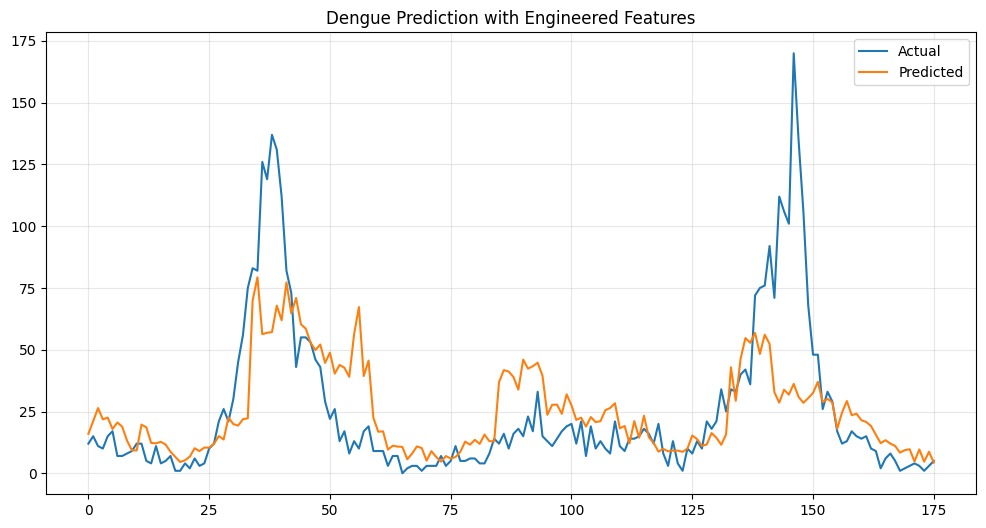

In [12]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(y_true.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.grid(True, alpha=0.3)
plt.title("Dengue Prediction with Engineered Features")
plt.legend()
plt.show()

*Figure 10. Experiment 4 Actual vs Predicted on Test Set*

Based on the scores, this model currently provides the best performance among all configurations tested with full preprocessing applied. This demonstrates the critical role of preprocessing in model training. Furthermore, as shown in *Figure 10*, the model exhibits strong sensitivity to high-amplitude spikes, representing outbreak conditions which indicates that the feature engineering steps effectively enhance the model’s ability to capture these extreme events.

## Feature Analysis 
### Mean Decrease Accuracy

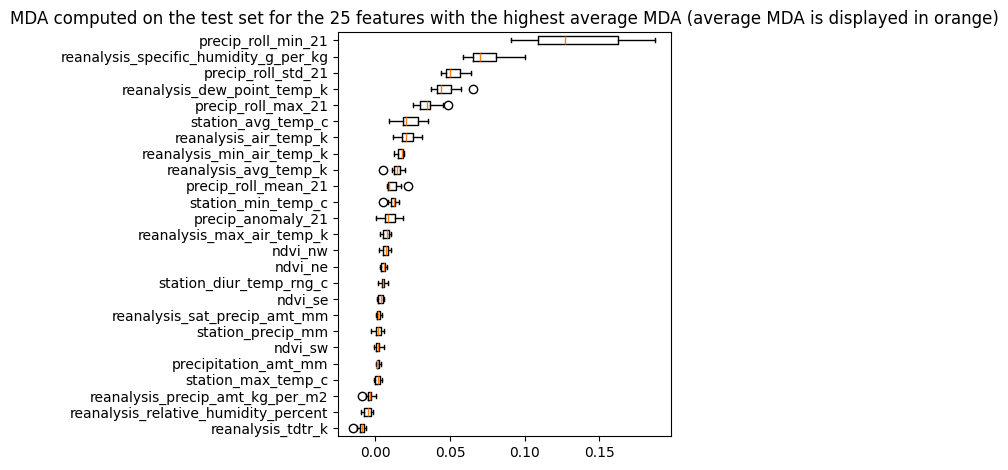

In [5]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, Xtest, Ytest, n_repeats=10, random_state=42, n_jobs=2)

# Plot of the MDA for the 20 features with the highest average MDA
sorted_idx = result.importances_mean.argsort()
fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T,
           vert=False, labels=Xtest.columns[sorted_idx])
ax.set_title("MDA computed on the test set for the 25 features with the highest average MDA (average MDA is displayed in orange)")
fig.tight_layout()
plt.show()

*Figure 11. Average Mean Decrease Accuracy ranked for all features.*

### Feature Importances

<BarContainer object of 25 artists>

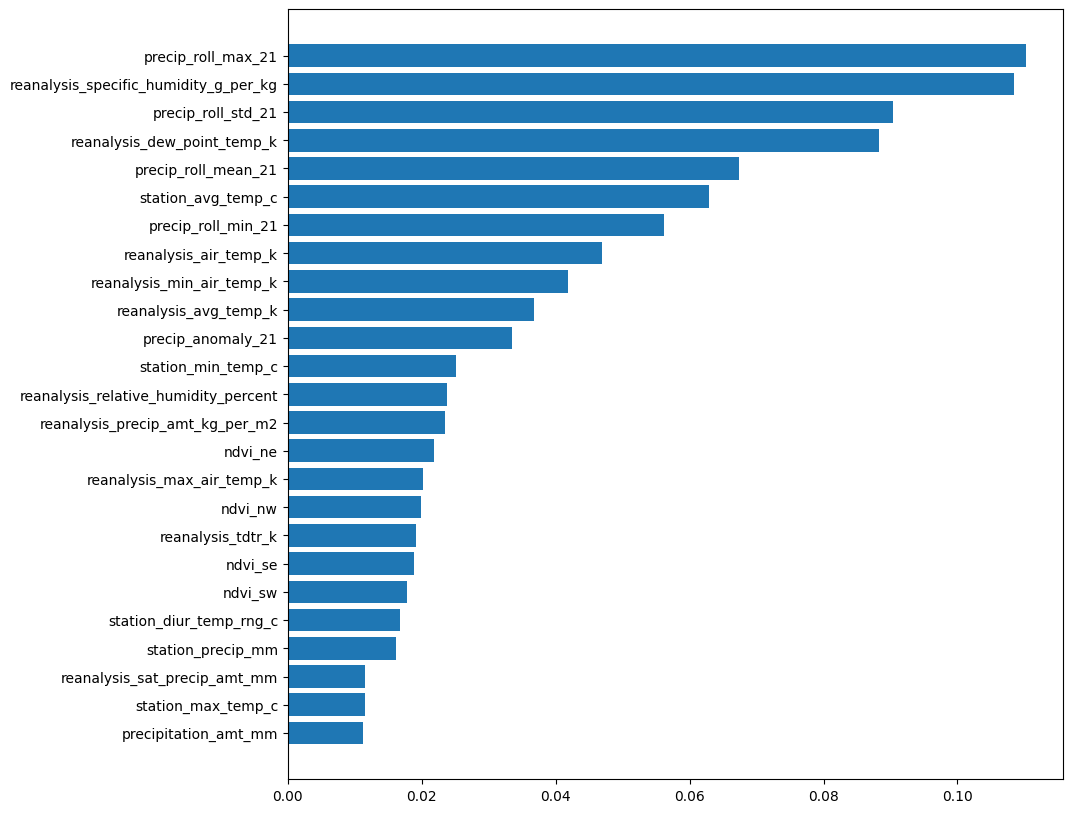

In [6]:
sorted_idx2 = rf.feature_importances_.argsort()
fig = plt.figure(figsize=(10,10))
plt.barh(X.columns[sorted_idx2], rf.feature_importances_[sorted_idx2])

*Figure 12. Impurity-based feature importance values.*

Based on the feature importances we decided to only keep top 5 features that explain the weekly dengue cases counts well.

In [13]:
def preprocess_data(df: pd.DataFrame, lag: int = 10, w: int = 21):
    # Defensive copy
    df = df.copy()

    # New features
    df[f"precip_roll_mean_{w}"] = df["station_precip_mm"].rolling(w).mean()
    df[f"precip_roll_std_{w}"] = df["station_precip_mm"].rolling(w).std()
    df[f"precip_roll_min_{w}"] = df["station_precip_mm"].rolling(w).min()
    df[f"precip_roll_max_{w}"] = df["station_precip_mm"].rolling(w).max()
    df[f"precip_anomaly_{w}"] = df["station_precip_mm"] - df[f"precip_roll_mean_{w}"]

    # Check that target column exists
    if 'total_cases' not in df.columns:
        raise ValueError("DataFrame must contain a 'total_cases' column as the target.")

    # Split features and target
    feature_cols = [c for c in df.columns if c != 'total_cases']
    
    # Interpolate missing values in features
    df[feature_cols] = df[feature_cols].interpolate(method='linear', limit_direction='both')

    # Shift features forward by lag (to make them predictive)
    df_shifted = df.copy()
    df_shifted[feature_cols] = df_shifted[feature_cols].shift(lag)

    # Log-transform the target
    df_shifted['total_cases'] = np.log1p(df_shifted['total_cases'])

    # Drop NaN rows introduced by shifting
    df_shifted = df_shifted.dropna().reset_index(drop=True)

    # Separate features and label
    X = df_shifted[feature_cols]
    y = df_shifted['total_cases']

    # Keep only high-importance features
    HIGH_IMPORTANCE_FEATURES = [
        f'precip_roll_max_{w}',
        'reanalysis_specific_humidity_g_per_kg',
        f'precip_roll_std_{w}',
        'reanalysis_dew_point_temp_k',
        f'precip_roll_mean_{w}',
    ]

    X = X[HIGH_IMPORTANCE_FEATURES]

    # Remove 'week_start_date' if present
    if 'week_start_date' in X.columns:
        X = X.drop(columns=['week_start_date'])

    return X, y, df_shifted


In [ ]:
# 21-week rolling window, 10-week lag
w = 21
lag = 10

X, Y, df_shifted = preprocess_data(sj_train_features, lag, w)

# time-series split (no shuffle)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# remove first lag rows to avoid leakage
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=int(X.shape[1] / 3), 
    random_state=42,
    max_depth=None,
    oob_score=True,
)

rf.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = rf.predict(Xtrain)

# Transform back from log1p
y_train_true = np.expm1(Ytrain)
y_train_pred = np.expm1(Ytrain_pred)

# Training errors
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors
Ypred = rf.predict(Xtest)

y_true = np.expm1(Ytest)
y_pred = np.expm1(Ypred)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")


Training MAE: 6.96
Training RMSE: 20.54
Test MAE: 14.17
Test RMSE: 21.48


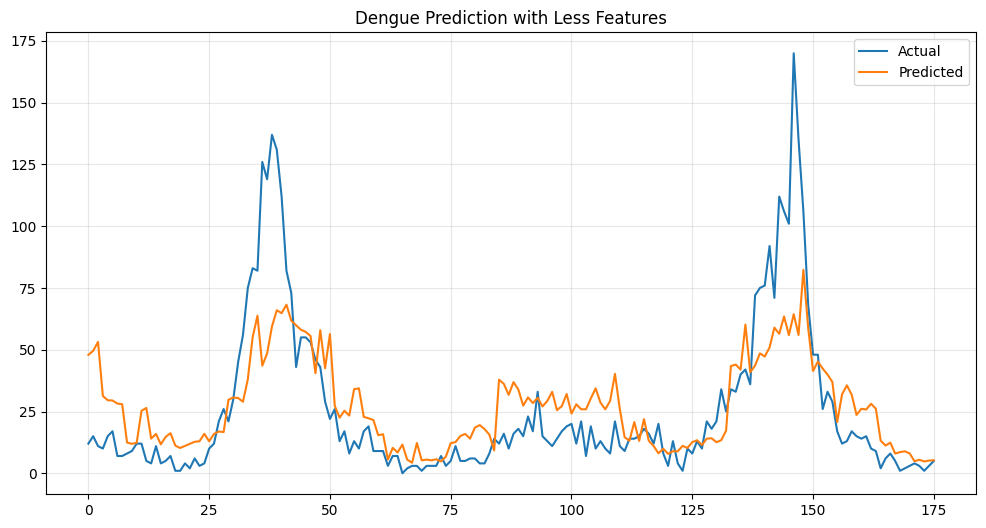

In [9]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(y_true.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.grid(True, alpha=0.3)
plt.title("Dengue Prediction with Less Features")
plt.legend()
plt.show()

*Figure 13. Actual vs Predicted on Test Set after important feature selection.*

As seen in figure 13, now the model can predict the pattern very well learning from only 5 features. 

## Hyperparameter Tuning

Hyperparameter tuning is an important step to further imporve the model's generalization performance. We decided to check if number of trees and max features influence the results.

### 1. Number of Estimators

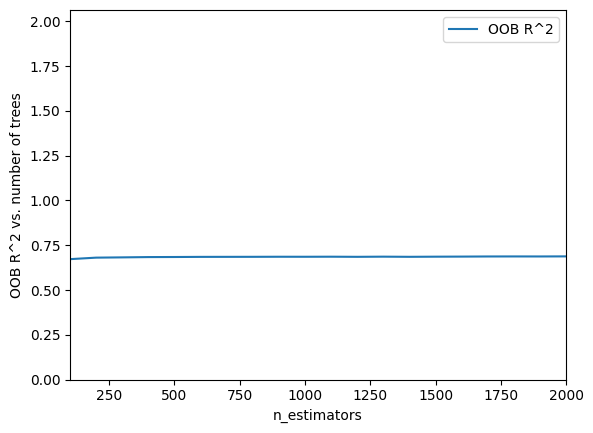

In [20]:
# Map a regressor name to a list of (<n_estimators>, <r2>) pairs.
r2 = []

# Range of `n_estimators` values to explore.
min_estimators = 100
max_estimators = 2000
step=100

for i in range(min_estimators, max_estimators+1, step):
    rf = RandomForestRegressor(warm_start=True, n_estimators=i, max_features=int(X.shape[1]/3), random_state=42, oob_score=True)
    rf.fit(X, Y)

    # Record the OOB R^2 for each `n_estimators=i` setting
    r2.append(rf.oob_score_)
  

# Plot Generate the "OOB R^2" vs. "n_estimators" plot

plt.plot(range(min_estimators, max_estimators +1, step), r2, label="OOB R^2")

plt.ylim(0, 3*max(r2)) 
plt.xlim(min_estimators, max_estimators)
plt.xlabel("n_estimators")
plt.ylabel("OOB R^2 vs. number of trees")
plt.legend(loc="upper right")
plt.show()

*Figure 14. Evolution OOB R^2 over n_executors.*

The figure above explains that number of trees do not influence the R^2 value. So we keep the `n_estimators` value of 500.

### 2. Max Features

In [21]:
def rolling_cv_tune_max_features(X, Y, max_features_list, lag=10):
    n = len(X)
    test_size = int(0.2 * n)
    val_size = int(0.2 * n)
    train_min = int(0.2 * n)
    train_max = int(0.6 * n)

    # Reserve final 20% as test set
    X_trainval, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    Y_trainval, Y_test = Y.iloc[:-test_size], Y.iloc[-test_size:]

    # Remove first `lag` samples from test set to avoid data leakage
    X_test = X_test.iloc[lag:].reset_index(drop=True)
    Y_test = Y_test.iloc[lag:].reset_index(drop=True)

    results = []

    print("Performing rolling cross-validation for max_features tuning...\n")

    for train_end in np.linspace(train_min, train_max, num=5, dtype=int):
        val_start = train_end
        val_end = val_start + val_size
        if val_end > len(X_trainval):
            break

        X_train = X_trainval.iloc[:train_end]
        Y_train = Y_trainval.iloc[:train_end]
        X_val = X_trainval.iloc[val_start:val_end]
        Y_val = Y_trainval.iloc[val_start:val_end]

        print(f"Rolling Split — Train: 0:{train_end}, Val: {val_start}:{val_end}")

        for mf in max_features_list:
            model = RandomForestRegressor(
                n_estimators=500,
                max_features=mf,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, Y_train)
            Y_val_pred = model.predict(X_val)

            # Convert back from log1p to original scale
            y_val_true = np.expm1(Y_val)
            y_val_pred = np.expm1(Y_val_pred)

            mae = mean_absolute_error(y_val_true, y_val_pred)
            rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))

            results.append({
                "train_end": train_end,
                "max_features": mf,
                "val_mae": mae,
                "val_rmse": rmse
            })

    results_df = pd.DataFrame(results)

    # Average performance across rolling splits
    avg_results = results_df.groupby("max_features")[["val_mae", "val_rmse"]].mean().reset_index()

    # Best hyperparameter
    best_mf = avg_results.loc[avg_results["val_mae"].idxmin(), "max_features"]
    print(f"\nBest max_features = {best_mf} (Mean Validation MAE: {avg_results['val_mae'].min():.3f})")

    # Retrain on full train+val and evaluate on test
    best_model = RandomForestRegressor(
        n_estimators=500,
        max_features=best_mf,
        random_state=42,
        n_jobs=-1
    )
    best_model.fit(X_trainval, Y_trainval)
    Y_test_pred = best_model.predict(X_test)

    y_true = np.expm1(Y_test)
    y_pred = np.expm1(Y_test_pred)

    mae_test = mean_absolute_error(y_true, y_pred)
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"Test MAE: {mae_test:.3f}, Test RMSE: {rmse_test:.3f}")

    # Plot validation curve
    plt.figure(figsize=(8,5))
    plt.plot(avg_results["max_features"], avg_results["val_mae"], marker='o', label="Validation MAE")
    plt.title("Validation MAE vs max_features")
    plt.xlabel("max_features")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

    return avg_results, best_mf, (mae_test, rmse_test), y_true, y_pred

Performing rolling cross-validation for max_features tuning...

Rolling Split — Train: 0:185, Val: 185:370
Rolling Split — Train: 0:277, Val: 277:462
Rolling Split — Train: 0:370, Val: 370:555
Rolling Split — Train: 0:462, Val: 462:647
Rolling Split — Train: 0:555, Val: 555:740

Best max_features = 1 (Mean Validation MAE: 26.439)
Test MAE: 13.998, Test RMSE: 21.224


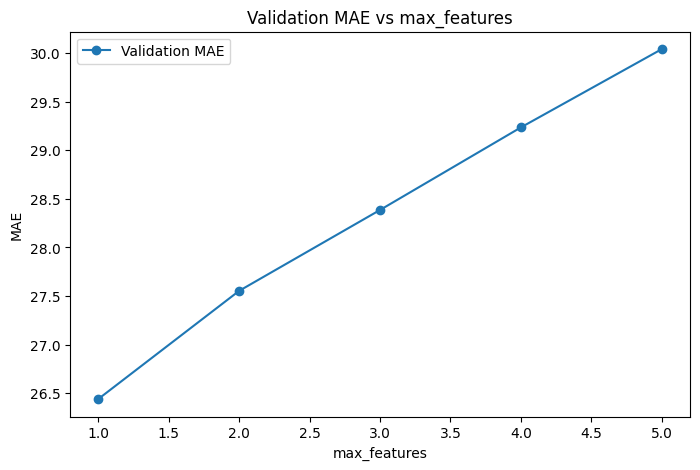

In [22]:
max_features_list = [1,2,3,4,5]
avg_results, best_mf, test_scores, y_true, y_pred = rolling_cv_tune_max_features(X, Y, max_features_list)

*Figure 15. Result of rolling cross-validation. Mean Absolute Error over max features.*

After performing the cross-validation to tune the `max_features` hyperparameter of our Random Forest model, we find the best value is equal to 1 or `number of features/3`.

## Final Random Forest Model

In [15]:
# 21-week rolling window anbd 10-week lag
w = 21
lag = 10

X, Y, df_shifted = preprocess_data(sj_train_features, lag, w)

# time-series split (no shuffle)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# remove first lag rows to avoid leakage
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=1, 
    random_state=42,
    max_depth=None,
    oob_score=True,
    criterion='absolute_error'
)

rf.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = rf.predict(Xtrain)

# Transform back from log1p
y_train_true = np.expm1(Ytrain)
y_train_pred = np.expm1(Ytrain_pred)

# Training errors
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors
Ypred = rf.predict(Xtest)
y_true = np.expm1(Ytest)
y_pred_rf = np.expm1(Ypred)

mae = mean_absolute_error(y_true, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_rf))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Training MAE: 7.37
Training RMSE: 21.82
MAE: 14.07
RMSE: 21.36


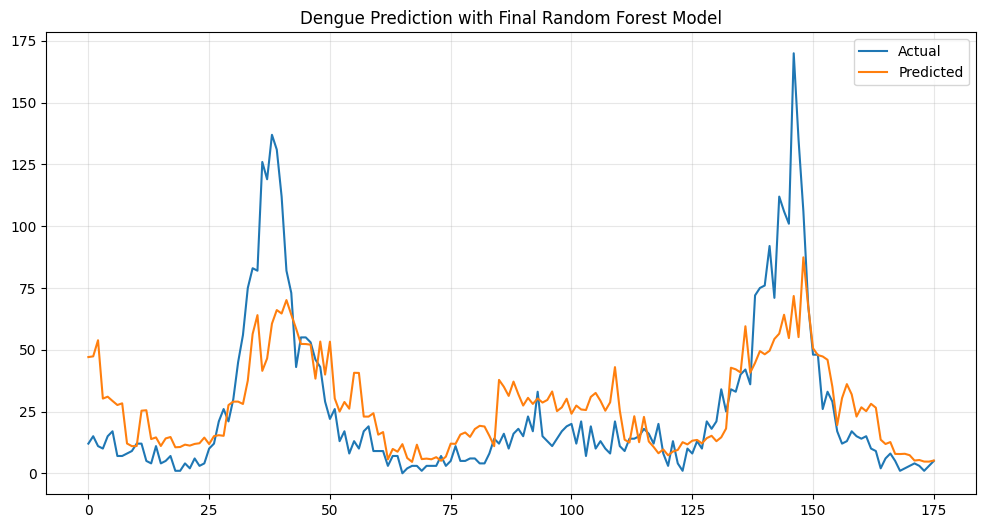

In [16]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(y_true.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")
plt.grid(True, alpha=0.3)
plt.title("Dengue Prediction with Final Random Forest Model")
plt.legend()
plt.show()

*Figure 16. Actual vs Predicted on Test Set after all the preprocessing steps.*

The final model still not perfect, but captures the underlying pattern of the weekly dengue cases (Figure 16). After all the preprocessing steps, the model predictions follow the seasonality of the actual changes. The MAE of ~14 cases is mostly due to the outbreaks and some overestimations in between. Overall, the feature engineering techniques we implemented greatly improved the model's performance by reducing the MAE by ~14 and RMSE by ~15 compared to the model with no preprocessing.

## 2. XGBoost
XGBoost is chosen as the second model because it is a gradient-boosting algorithm that builds trees sequentially, with each new tree correcting the errors of the previous ones. This makes it highly effective at capturing complex, non-linear relationships in the data. For our dengue dataset, where environmental variables interact in irregular and sometimes subtle ways, XGBoost is well-suited to model these dynamics and potentially detect outbreak-related patterns that may not be captured by simpler or purely ensemble-averaging methods.

In [17]:
from xgboost import XGBRegressor

# 21-week rolling window anbd 10-week lag
w = 21
lag = 10

X, Y, df_shifted = preprocess_data(sj_train_features, lag, w)

# time-series split (no shuffle)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# remove first lag rows to avoid leakage
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

xgbr = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgbr.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = xgbr.predict(Xtrain)

# Transform back from log1p
y_train_true = np.expm1(Ytrain)
y_train_pred = np.expm1(Ytrain_pred)

# Training errors
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors
Ypred = xgbr.predict(Xtest)

y_true = np.expm1(Ytest)
y_pred = np.expm1(Ypred)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Training MAE: 3.09
Training RMSE: 7.04
MAE: 16.33
RMSE: 23.73


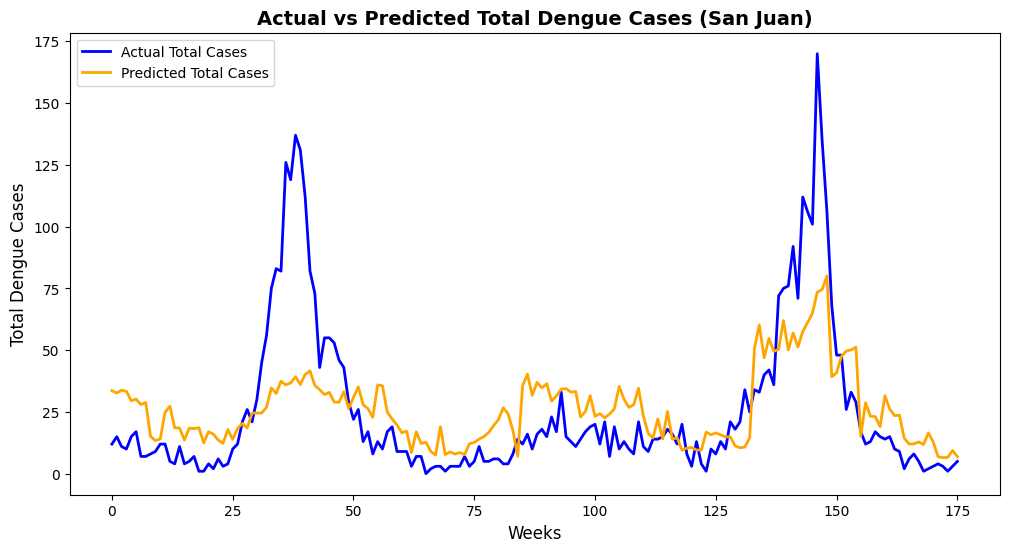

In [18]:
# plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_true.values, label='Actual Total Cases', color='blue', linewidth=2)
plt.plot(y_pred, label='Predicted Total Cases', color='orange', linewidth=2)
plt.title('Actual vs Predicted Total Dengue Cases (San Juan)', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Dengue Cases', fontsize=12)
plt.legend()
plt.show()

*Figure 17. XGBoost Actual vs Predicted on Test Set (no hyperparameter tuning).*

### Hyperparameter tuning: XGBoost

In [15]:
def rolling_cv_tune_xgb(
        X, Y,
        param_grid=None,
        lag=10
    ):
    """
    Rolling CV tuning for XGBoost using log1p-transformed targets
    and expanding window cross-validation.
    """

    if param_grid is None:
        param_grid = {
            "learning_rate": [0.005, 0.01, 0.05, 0.1],
            "max_depth": [3, 4, 5, 6],
            "min_child_weight": [1, 3, 5, 10],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0],
            "gamma": [0, 1, 3]
        }

    # -------------------------------
    # 1. Split: 60% trainval, 20% val, 20% test
    # -------------------------------
    n = len(X)
    test_size = int(0.2 * n)
    val_size = int(0.2 * n)
    train_min = int(0.2 * n)
    train_max = int(0.6 * n)

    X_trainval, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
    Y_trainval, Y_test = Y.iloc[:-test_size], Y.iloc[-test_size:]

    # Avoid leakage: remove first lag from test
    X_test = X_test.iloc[lag:].reset_index(drop=True)
    Y_test = Y_test.iloc[lag:].reset_index(drop=True)

    results = []

    print("Performing rolling cross-validation for XGBoost tuning...\n")

    # -------------------------------
    # 2. Rolling CV over 5 splits
    # -------------------------------
    for train_end in np.linspace(train_min, train_max, num=5, dtype=int):

        val_start = train_end
        val_end = val_start + val_size
        if val_end > len(X_trainval):
            break

        X_train = X_trainval.iloc[:train_end]
        Y_train = Y_trainval.iloc[:train_end]
        X_val = X_trainval.iloc[val_start:val_end]
        Y_val = Y_trainval.iloc[val_start:val_end]

        print(f"Rolling Split — Train: 0:{train_end}, Val: {val_start}:{val_end}")

        # Iterate through parameter combinations
        for lr in param_grid["learning_rate"]:
            for md in param_grid["max_depth"]:
                for mcw in param_grid["min_child_weight"]:
                    for ss in param_grid["subsample"]:
                        for cs in param_grid["colsample_bytree"]:
                            for gm in param_grid["gamma"]:

                                model = XGBRegressor(
                                    n_estimators=500,
                                    learning_rate=lr,
                                    max_depth=md,
                                    min_child_weight=mcw,
                                    subsample=ss,
                                    colsample_bytree=cs,
                                    gamma=gm,
                                    objective="reg:squarederror",
                                    tree_method="hist",
                                    random_state=42,
                                    n_jobs=-1
                                )

                                model.fit(X_train, Y_train)

                                Y_val_pred = model.predict(X_val)

                                # Reverse log-transform
                                y_val_true = np.expm1(Y_val)
                                y_val_pred = np.expm1(Y_val_pred)

                                mae = mean_absolute_error(y_val_true, y_val_pred)
                                rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))

                                results.append({
                                    "train_end": train_end,
                                    "learning_rate": lr,
                                    "max_depth": md,
                                    "min_child_weight": mcw,
                                    "subsample": ss,
                                    "colsample_bytree": cs,
                                    "gamma": gm,
                                    "val_mae": mae,
                                    "val_rmse": rmse
                                })

    results_df = pd.DataFrame(results)

    # -------------------------------
    # 3. Average performance for each param combination
    # -------------------------------
    hp_cols = ["learning_rate", "max_depth", "min_child_weight",
               "subsample", "colsample_bytree", "gamma"]

    avg_results = (
        results_df.groupby(hp_cols)[["val_mae", "val_rmse"]]
        .mean()
        .reset_index()
    )

    # Pick best combination (lowest mean MAE)
    best_idx = avg_results["val_mae"].idxmin()
    best_params = avg_results.loc[best_idx, hp_cols].to_dict()

    best_params["max_depth"] = int(best_params["max_depth"])
    best_params["min_child_weight"] = int(best_params["min_child_weight"])

    print("\nBest Parameters Found:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")

    print(f"\nMean Validation MAE: {avg_results['val_mae'].min():.3f}")

    # -------------------------------
    # 4. Retrain on full train+val with best params
    # -------------------------------
    best_model = XGBRegressor(
        n_estimators=500,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **best_params
    )

    best_model.fit(X_trainval, Y_trainval)

    Y_test_pred = best_model.predict(X_test)

    y_true = np.expm1(Y_test)
    y_pred = np.expm1(Y_test_pred)

    mae_test = mean_absolute_error(y_true, y_pred)
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\nTest MAE: {mae_test:.3f}")
    print(f"Test RMSE: {rmse_test:.3f}")

    # -------------------------------
    # 5. Plot MAE vs learning_rate as an example curve
    # -------------------------------
    plt.figure(figsize=(8,5))
    lr_mae = avg_results.groupby("learning_rate")["val_mae"].mean()
    lr_mae.plot(marker="o")
    plt.title("Validation MAE vs learning_rate")
    plt.xlabel("learning_rate")
    plt.ylabel("MAE")
    plt.show()

    return avg_results, best_params, (mae_test, rmse_test), y_true, y_pred

Performing rolling cross-validation for XGBoost tuning...

Rolling Split — Train: 0:185, Val: 185:370
Rolling Split — Train: 0:277, Val: 277:462
Rolling Split — Train: 0:370, Val: 370:555
Rolling Split — Train: 0:462, Val: 462:647
Rolling Split — Train: 0:555, Val: 555:740

Best Parameters Found:
  learning_rate: 0.1
  max_depth: 3
  min_child_weight: 1
  subsample: 1.0
  colsample_bytree: 0.7
  gamma: 3.0

Mean Validation MAE: 25.018

Test MAE: 15.537
Test RMSE: 25.255


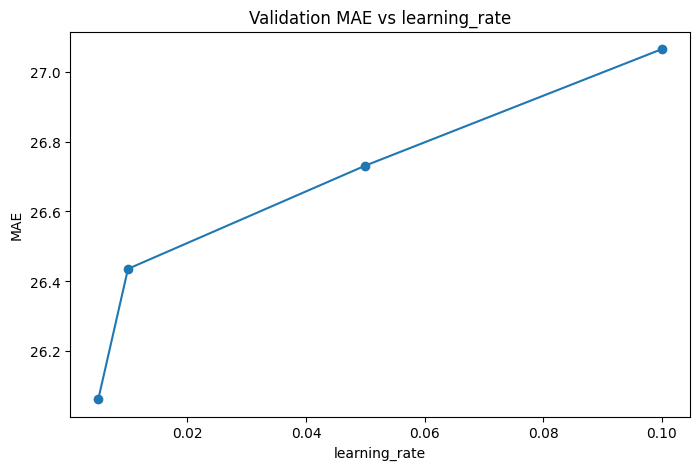

In [16]:
avg_results, best_mf, test_scores, y_true, y_pred = rolling_cv_tune_xgb(X, Y, lag=10)

## 3. RandomForestRegressor vs XGBoost (+ DummyRegressor)

### Training a Single Decision Tree for comparison

In [19]:
from sklearn.tree import DecisionTreeRegressor

# 21-week rolling window anbd 10-week lag
w = 21
lag = 10

X, Y, df_shifted = preprocess_data(sj_train_features, lag, w)

# time-series split (no shuffle)
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, shuffle=False)

# remove first lag rows to avoid leakage
Xtest = Xtest.iloc[lag:].reset_index(drop=True)
Ytest = Ytest.iloc[lag:].reset_index(drop=True)

tree_reg = DecisionTreeRegressor(
    max_depth=int(X.shape[1]/3),
    random_state=42
)

tree_reg.fit(Xtrain, Ytrain)

# Training predictions
Ytrain_pred = tree_reg.predict(Xtrain)

# Transform back from log1p
y_train_true = np.expm1(Ytrain)
y_train_pred = np.expm1(Ytrain_pred)

# Training errors
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f"Training MAE: {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")

# Test errors
Ypred = tree_reg.predict(Xtest)

y_true = np.expm1(Ytest)
y_pred_tree = np.expm1(Ypred)

mae = mean_absolute_error(y_true, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_tree))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Training MAE: 23.58
Training RMSE: 54.16
MAE: 18.74
RMSE: 28.64


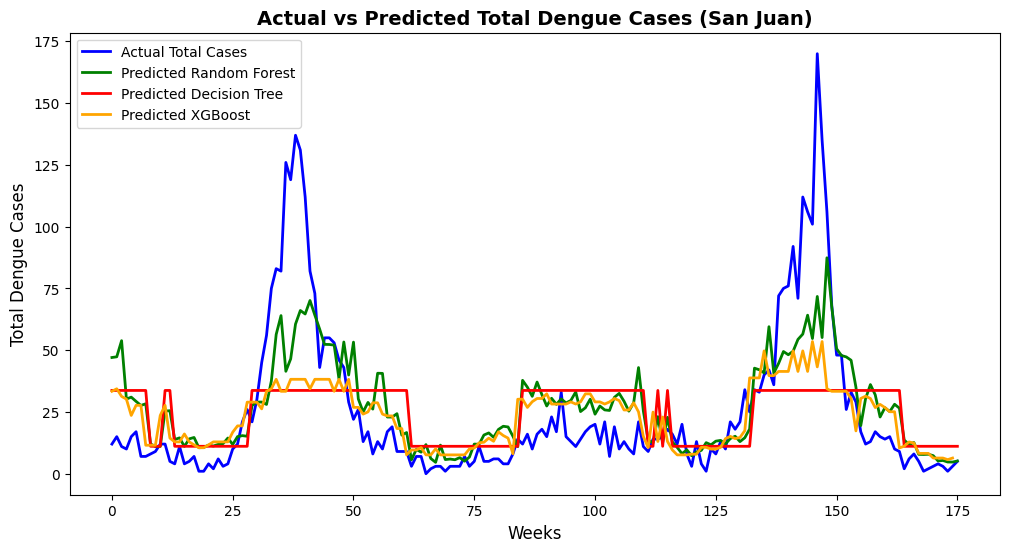

In [20]:
# plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(y_true.values, label='Actual Total Cases', color='blue', linewidth=2)
plt.plot(y_pred_rf, label='Predicted Random Forest', color='green', linewidth=2)
plt.plot(y_pred_tree, label='Predicted Decision Tree', color='red', linewidth=2)
plt.plot(y_pred, label='Predicted XGBoost', color='orange', linewidth=2)
plt.title('Actual vs Predicted Total Dengue Cases (San Juan)', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Dengue Cases', fontsize=12)
plt.legend()
plt.show()

*Figure 18. Random Forest, XGBoost, Decision Tree Actual vs Predicted on Test Set.*

## Theoretical and Empirical Advantages and Disadvantages of RandomForestRegressor and XGBoost

| RandomForestRegressor | XGBoost |
|-----------------------|---------|
| Ensemble of decision trees trained on bootstrapped samples; reduces variance through averaging. | Gradient-boosted trees trained sequentially, each model correcting previous errors. |
| Stable, robust to noise, low sensitivity to hyperparameters, and easier to interpret. | Often achieves higher accuracy, models complex non-linear interactions effectively. |
| May struggle with sharp rare events and can underfit if not deep enough. | Sensitive to hyperparameters, more computationally expensive, higher risk of overfitting. |
| Simple to deploy, cheaper to run, and operationally stable in public health settings. | More complex pipeline and higher maintenance burden. |


## Questions
**1. If you had to advise a company or a research institute, explain the algorithm you would deploy. Justify your choice.**

**Answer** : We would recommend deploying a *Random Forest Regressor* model. The dengue case series displays seasonal behaviour with occasional outbreak spikes, and Random Forests are well-suited to this kind of structure. They handle non-linear patterns, tolerate noisy variables, and remain stable even when the data contains mixed signals such as gradual seasonal changes alongside sudden surges in cases. 

From an operational perspective, Random Forests are easier to maintain, require modest computational resources, and provide clear interpretability through feature importance and tree-based explanations. This makes them practical for public health settings where predictions must be both reliable and explainable to domain experts such as epidemiologists.

**2. If you had a 3-month extra to work on this problem, what experiment would you run? Justify what it will bring to the analysis**

**Answer** :If given an additional three months, we would focus on expanding the dataset beyond environmental variables. The current model behaviour still suggests that important aspects of dengue transmission are missing. Adding information related to human movement, mosquito population indicators, urban structure, or socio-economic conditions would help capture the mechanisms that drive dengue risk more accurately. Bringing these elements into the feature set would provide a more realistic picture of transmission dynamics and likely improve both accuracy and early detection of outbreaks.

In addition, we would explore more advanced modelling approaches designed to handle irregular events and structural shifts, such as boosted ensembles or specialised time-series architectures. These models often perform better when the goal is to detect rare but high-impact events like outbreaks. Combining richer data with more capable modelling strategies would allow the forecasting system to become more robust, informative, and operationally valuable.
